# Arm A — Global (Non-Stratified) Baseline

This notebook implements Arm A of the study: a single classifier trained on the full patient population without stratification. Arm A provides the baseline against which the sex-based clinical subgroups of Arm B and the k-prototypes clusters of Arm C are compared.

All three arms use the same features, the same two classifiers, the same preprocessing procedure, the same hyperparameter-selection procedure, the same evaluation protocol, and the same outer cross-validation fold partitions. The only intended difference between arms is the stratification strategy, so that any difference observed between arms can be attributed to how patient heterogeneity is handled rather than to differences in modelling conditions.

## 2. Imports and configuration

RANDOM_STATE is fixed so that every step involving randomness (fold assignment and model fitting) is reproducible: rerunning this notebook produces the same folds, the same hyperparameter choices, and the same results.

K_OUTER and K_INNER are both set to 5. The Cleveland subset is a small dataset (on the order of 300 patients), so 5 folds balances having enough patients per fold against having enough folds to average over. The outer folds provide the held-out data used to report performance; the inner folds are used only within each outer training fold to select hyperparameters, so hyperparameter selection never has access to the corresponding outer validation data.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Configuration
RANDOM_STATE = 42
K_OUTER      = 5
K_INNER      = 5

## 3. Load dataset

The modelling data is the cleaned Cleveland extract produced by data_cleaning.ipynb.

In [2]:
df = pd.read_csv("heart+disease/cleveland_clean.csv")
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (297, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,check
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,False
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,True
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,True
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,False
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,False


## 4. Target construction

The original Cleveland target, `num`, represents the presence/severity of heart disease. For binary classification, observations with `num = 0` are coded as class 0 (absence of disease), while observations with `num > 0` are coded as class 1 (presence of disease).

The dataset also contains a derived column, `check`, equal to `num > 0`. Because `check` is derived directly from the target, it is excluded from the feature matrix together with `num`: retaining a derived copy of the label as a feature would let the model see the answer instead of learning from the clinical features, which is a form of data leakage.

In [3]:
target_col = "num"

y = (df[target_col] > 0).astype(int)
X = df.drop(columns=[target_col, "check"], errors="ignore")

print("Samples:", len(df), " Features:", X.shape[1])
print("Class balance:")
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print("Positive rate: {:.3f}".format(y.mean()))

Samples: 297  Features: 13
Class balance:
num
no disease    160
disease       137
Name: count, dtype: int64
Positive rate: 0.461


## 5. Feature definition

Features are grouped by type, following the preprocessing rules in the proposal (Section 3.2): continuous features are standardised, nominal category codes are one-hot encoded, and binary or count features are passed through unchanged. `ca` is treated as numeric because it represents a count of major vessels rather than an unordered category.

In [4]:
continuous  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
nominal     = ["cp", "restecg", "slope", "thal"]
passthrough = ["sex", "fbs", "exang", "ca"]

print("Continuous:", continuous)
print("Nominal (one-hot encoded):", nominal)
print("Passthrough (already binary/count):", passthrough)

Continuous: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Nominal (one-hot encoded): ['cp', 'restecg', 'slope', 'thal']
Passthrough (already binary/count): ['sex', 'fbs', 'exang', 'ca']


## 6. Exploratory checks

The target classes are moderately balanced (approximately 54% vs 46%), so no class-balancing procedure is applied, consistent with the proposal.

num
no disease    160
disease       137
Name: count, dtype: int64

num
no disease    0.539
disease       0.461
Name: proportion, dtype: float64


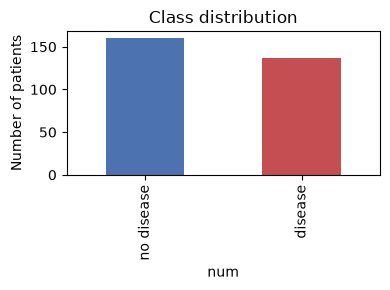

In [5]:
print(y.value_counts().rename({0: "no disease", 1: "disease"}))
print()
print(y.value_counts(normalize=True).rename({0: "no disease", 1: "disease"}).round(3))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().rename({0: "no disease", 1: "disease"}).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of patients")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

## 7. Preprocessing

Preprocessing steps that estimate parameters from the data (the mean/standard deviation used for scaling, the set of categories seen for one-hot encoding) are wrapped inside a scikit-learn `Pipeline` together with each classifier, rather than being fitted once on the full dataset. Because `GridSearchCV` refits this pipeline separately on each training fold during cross-validation, the scaler and encoder only ever see training-fold data, preventing information from the validation folds from leaking into preprocessing.

In [6]:
# Fitted only inside the pipeline, on training-fold data (see Section 10), never on the full dataset.
preprocess = ColumnTransformer([
    ("num",  StandardScaler(),                       continuous),
    ("cat",  OneHotEncoder(handle_unknown="ignore"),  nominal),
    ("pass", "passthrough",                           passthrough),
])

## 8. Fixed outer-fold construction

The proposal requires that all three arms are evaluated on the same outer cross-validation fold partitions (Section 3.5). Every patient is assigned a fold id once, stratified by the target, and the assignment is saved to `fold_id.csv`. If this file already exists, it is loaded and reused instead of being regenerated, so that Arm A, Arm B, and Arm C always evaluate the same patients in the same folds. `StratifiedKFold`, rather than a plain random split, is used because the classes are not perfectly balanced (163 vs 138), and stratification keeps the class ratio similar across folds.

In [7]:
FOLD_FILE = "fold_id.csv"

if os.path.exists(FOLD_FILE):
    fold_id = pd.read_csv(FOLD_FILE)["fold"].to_numpy()
    if len(fold_id) != len(df):
        raise ValueError(
            f"{FOLD_FILE} has {len(fold_id)} entries but the current dataset has {len(df)} rows; "
            "delete or regenerate the fold file before proceeding."
        )
    print(f"Loaded existing fold assignment from {FOLD_FILE}.")
else:
    skf = StratifiedKFold(n_splits=K_OUTER, shuffle=True, random_state=RANDOM_STATE)
    fold_id = np.empty(len(df), dtype=int)
    for k, (_, val_idx) in enumerate(skf.split(X, y)):
        fold_id[val_idx] = k
    pd.Series(fold_id, name="fold").to_csv(FOLD_FILE, index=False)
    print(f"Created new fold assignment and saved to {FOLD_FILE}.")

print("Fold sizes:", np.bincount(fold_id))
print("Positives per fold:", np.bincount(fold_id[y.values == 1]))

Loaded existing fold assignment from fold_id.csv.
Fold sizes: [60 60 59 59 59]
Positives per fold: [28 28 27 27 27]


## 9. Model definitions and hyperparameter grids

Two classifiers are used: logistic regression, an interpretable linear model, and random forest, a non-linear comparator. Each is given a small hyperparameter grid; the study compares stratification strategies rather than searching for the best-performing classifier, so no extensive optimisation is performed. The same classifiers, grids, and tuning procedure are intended to be reused unchanged in Arm B and Arm C, so that any difference between arms reflects the stratification strategy rather than the modelling choices.

In [8]:
models = {
    "logreg": (
        Pipeline([("pre", preprocess),
                  ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        {"clf__C": [0.01, 0.1, 1, 10]},
    ),
    "rf": (
        Pipeline([("pre", preprocess),
                  ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 5, 10]},
    ),
}

## 10. Nested cross-validation

For each model and each outer fold, hyperparameters are selected using `GridSearchCV` with an inner stratified cross-validation on the training portion of that fold only; the outer validation fold is never used during hyperparameter selection. ROC-AUC is used as the tuning criterion (`scoring="roc_auc"`) because it is threshold-independent and is one of the three metrics reported for all arms; accuracy, F1-score, and ROC-AUC are then computed on the held-out outer fold using the selected hyperparameters. Predicted class labels use a fixed probability threshold of 0.5, applied identically in every fold, model, and arm, so that thresholding does not become a source of variation between arms.

In [9]:
fold_results = []
oof_rows = []
patient_id = df.index.to_numpy()

for name, (pipe, grid) in models.items():
    for k in range(K_OUTER):
        train, validation = (fold_id != k), (fold_id == k)

        # Hyperparameter selection uses only the training portion of this outer
        # fold; the outer validation fold is not seen until scoring below.
        inner = StratifiedKFold(n_splits=K_INNER, shuffle=True, random_state=RANDOM_STATE)
        search = GridSearchCV(pipe, grid, cv=inner, scoring="roc_auc", n_jobs=-1)
        search.fit(X[train], y[train])

        best = search.best_estimator_
        proba = best.predict_proba(X[validation])[:, 1]  # Predicted probability of the positive class (heart disease)
        pred  = (proba >= 0.5).astype(int)                # Fixed threshold, held constant across arms

        fold_results.append({
            "model": name,
            "fold": k,
            "accuracy": accuracy_score(y[validation], pred),
            "f1": f1_score(y[validation], pred),
            "roc_auc": roc_auc_score(y[validation], proba),
            "best_params": search.best_params_,
        })

        y_val = y[validation].to_numpy()
        for pid, yt, p, c in zip(patient_id[validation], y_val, proba, pred):
            oof_rows.append({
                "patient_id": int(pid), "fold": int(k), "y_true": int(yt),
                "model": name, "proba": float(p), "pred": int(c),
            })

fold_results_df = pd.DataFrame(fold_results)
print("Nested cross-validation complete:", len(fold_results_df), "model x fold rows")

Nested cross-validation complete: 10 model x fold rows


## 11. Fold-level results

Individual outer-fold metrics are retained, in addition to the summary statistics in the next section, so that Arm B and Arm C can later be compared fold-by-fold rather than only through aggregate means.

In [10]:
fold_results_display = fold_results_df.drop(columns=["best_params"]).round(3)
fold_results_df.to_csv("armA_fold_results.csv", index=False)
print("Saved armA_fold_results.csv")
fold_results_display

Saved armA_fold_results.csv


,model,fold,accuracy,f1,roc_auc
0,logreg,0,0.917,0.909,0.948
1,logreg,1,0.833,0.815,0.908
2,logreg,2,0.746,0.727,0.834
3,logreg,3,0.847,0.816,0.887
4,logreg,4,0.864,0.833,0.935
5,rf,0,0.900,0.893,0.949
6,rf,1,0.817,0.800,0.910
7,rf,2,0.729,0.692,0.816
8,rf,3,0.780,0.745,0.869
9,rf,4,0.847,0.816,0.949


## 12. Overall performance summary

Mean and standard deviation across the 5 outer folds are reported for each model, rather than a single point estimate, so that both average performance and its variability across folds can be assessed.

In [11]:
results = (
    fold_results_df
    .groupby("model")[["accuracy", "f1", "roc_auc"]]
    .agg(["mean", "std"])
)
results.columns = ["accuracy_mean", "accuracy_std", "f1_mean", "f1_std", "rocauc_mean", "rocauc_std"]
results = results.reset_index()

for _, row in results.iterrows():
    print(f"{row['model']:7s} | ACC {row['accuracy_mean']:.3f} +/- {row['accuracy_std']:.3f}"
          f" | F1 {row['f1_mean']:.3f} +/- {row['f1_std']:.3f}"
          f" | AUC {row['rocauc_mean']:.3f} +/- {row['rocauc_std']:.3f}")

results.to_csv("armA_results.csv", index=False)
print("Saved armA_results.csv")
results.set_index("model").round(3)

logreg  | ACC 0.842 +/- 0.062 | F1 0.820 +/- 0.065 | AUC 0.902 +/- 0.045
rf      | ACC 0.815 +/- 0.065 | F1 0.789 +/- 0.076 | AUC 0.899 +/- 0.057
Saved armA_results.csv


,accuracy_mean,accuracy_std,f1_mean,f1_std,rocauc_mean,rocauc_std
model,,,,,,
logreg,0.842,0.062,0.820,0.065,0.902,0.045
rf,0.815,0.065,0.789,0.076,0.899,0.057


## 13. Out-of-fold predictions

For every patient, the out-of-fold prediction from the one outer fold in which they were held out is retained, together with the patient identifier, fold id, true label, model name, predicted probability, and predicted class. This per-patient record is what allows Arm A, Arm B, and Arm C to be compared on identical patients rather than only through aggregate metrics.

In [12]:
oof_df = pd.DataFrame(oof_rows)
oof_df.to_csv("armA_predictions.csv", index=False)
print("Saved armA_predictions.csv:", oof_df.shape)
oof_df.head()

Saved armA_predictions.csv: (594, 6)


,patient_id,fold,y_true,model,proba,pred
0,1,0,1,logreg,0.964617,1
1,2,0,1,logreg,0.962592,1
2,6,0,1,logreg,0.741595,1
3,8,0,1,logreg,0.839588,1
4,10,0,0,logreg,0.464948,0


## 14. Interpretation / notes

On this dataset, logistic regression and random forest perform similarly, with overlapping standard deviations across folds; neither model is treated as final, since Arm A's purpose is to provide a comparison baseline rather than to select a preferred classifier.

For comparability with Arm B and Arm C:

- The nominal/continuous/passthrough feature grouping and the treatment of `ca` as numeric should be reused unchanged in Arm B and Arm C, so that the three arms differ only in stratification and not in feature representation.
- `fold_id.csv`, once created here, should be loaded by Arm B and Arm C rather than regenerated, so all arms evaluate the same patients in the same folds.
- Arm C's k-prototypes clustering must be fitted using only the training portion of each outer fold, as specified in the proposal, so that cluster assignment does not leak validation-fold information; this notebook does not perform any clustering or stratification, consistent with Arm A's role as the non-stratified baseline.